In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

-----------
# Ознайомлення з дата-сетом


In [2]:
df = pd.read_csv("../data/test_1_payment_data/test_1_payment_data.csv")
df.head(3)

,#,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
0,1,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39.000000,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM
1,2,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36.000000,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA
2,3,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32.000000,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.0,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND


In [3]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 566413 entries, 0 to 566412
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   #                   566413 non-null  int64  
 1   order_id            566413 non-null  str    
 2   event_time          566413 non-null  str    
 3   user_id             566413 non-null  str    
 4   price               566413 non-null  float64
 5   payment_number      566413 non-null  str    
 6   transaction_status  566413 non-null  str    
 7   card_brand          566413 non-null  str    
 8   card_type           565643 non-null  str    
 9   bank_name           564404 non-null  str    
 10  error_type          313048 non-null  float64
 11  currency            566413 non-null  str    
 12  card_country        565886 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 360.5 MB


--------

# Робота з датою
- Переведення колонки event_time в datetime формат
- Додавання нових фіч

**це нам дає можливість досліджувати сезонність, інтервали**

In [4]:
df['event_time'] = pd.to_datetime(df['event_time'])

print("Перевірка, чи тільки 2022 рік в дата-сеті:\n ",df['event_time'].dt.year.value_counts())

df['month'] = df['event_time'].dt.month
df['day'] = df['event_time'].dt.day
df['hour'] = df['event_time'].dt.hour
df['minute'] = df['event_time'].dt.minute
df['dayofweek'] = df['event_time'].dt.dayofweek

df.head(1)

Перевірка, чи тільки 2022 рік в дата-сеті:
  event_time
2022    566413
Name: count, dtype: int64


,#,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country,month,day,hour,minute,dayofweek
0,1,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM,7,8,18,32,4


--------------
# Описова статистика:

In [5]:
print("Загальна кількість транзакцій: ",df.shape[0])
print("Кількість унікальних user: ", df['user_id'].nunique())
print("Кількість дублікатів:", df.duplicated().sum())

missing_data = df.isnull().sum()
print("\nПропущені дані:\n", missing_data[missing_data > 0])

Загальна кількість транзакцій:  566413
Кількість унікальних user:  115245
Кількість дублікатів: 0

Пропущені дані:
 card_type          770
bank_name         2009
error_type      253365
card_country       527
dtype: int64


In [6]:
missing_pct = (missing_data[missing_data > 0] / len(df) * 100).round(2)
print("Частка пропусків (%):\n", missing_pct)

Частка пропусків (%):
 card_type        0.14
bank_name        0.35
error_type      44.73
card_country     0.09
dtype: float64


In [7]:
cat_cols = ['transaction_status', 'payment_number', 'card_brand', 'card_type', 'currency']
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- transaction_status ---
transaction_status
fail       313954
success    252459
Name: count, dtype: int64

--- payment_number ---
payment_number
reccurent    424081
initial      142332
Name: count, dtype: int64

--- card_brand ---
card_brand
VISA              362953
MASTERCARD        191957
AMEX                6884
DISCOVER            1912
RUPAY               1575
MAESTRO              537
DINERS CLUB          204
VERVE                203
CHINA UNIONPAY        74
LOCAL BRAND           57
ELO                   24
NSPK MIR              16
PRIVATE LABEL          5
TROY                   4
AIRPLUS                3
ATM CARD               1
EBT                    1
DINACARD               1
INSTAPAYMENT           1
JCB                    1
Name: count, dtype: int64

--- card_type ---
card_type
DEBIT             369968
CREDIT            140583
PREPAID            53396
DEFERRED DEBIT      1164
NaN                  770
CREDIT/DEBIT         518
CHARGE CARD           14
Name: count, dtype: int64


In [8]:
success_rate = (df['transaction_status'] == 'success').mean() * 100
print(f"Загальний success rate: {success_rate:.2f}%")

Загальний success rate: 44.57%


count    115245.000000
mean          4.914860
std           6.431247
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max         109.000000
dtype: float64


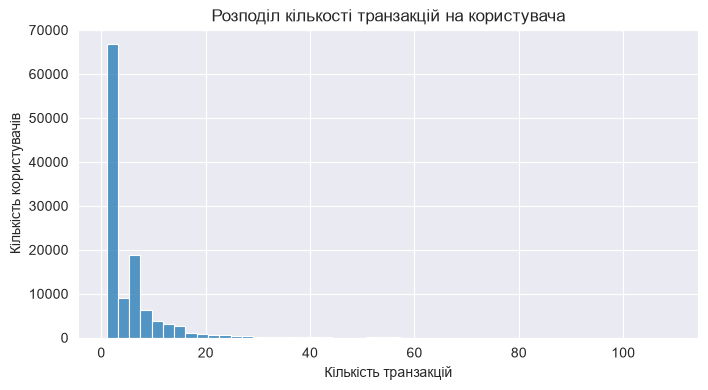

In [9]:
tx_per_user = df.groupby('user_id').size()
print(tx_per_user.describe())

plt.figure(figsize=(8, 4))
sns.histplot(tx_per_user, bins=50)
plt.title('Розподіл кількості транзакцій на користувача')
plt.xlabel('Кількість транзакцій')
plt.ylabel('Кількість користувачів')
plt.show()

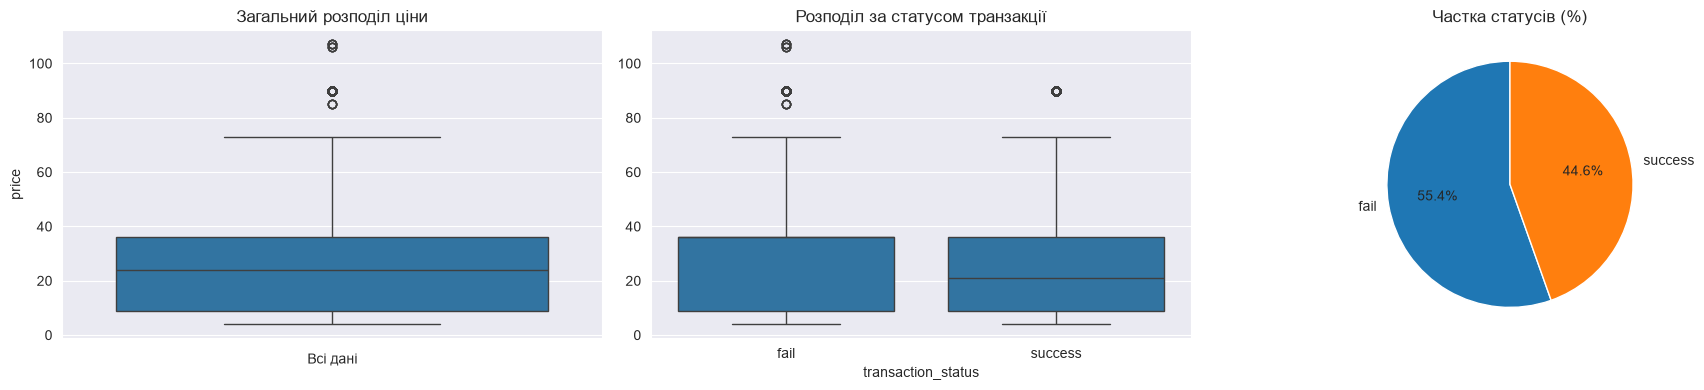

--- Загальна статистика ---
count    566413.000000
mean         24.641491
std          15.621955
min           4.000000
25%           9.000000
50%          24.000000
75%          36.000000
max         107.000000
Name: price, dtype: float64

--- Статистика за статусами ---


,count,mean,std,min,25%,50%,75%,max
transaction_status,,,,,,,,
fail,313954.0,26.658667,16.692784,4.0,9.0,36.0,36.0,107.0
success,252459.0,22.132964,13.771750,4.0,9.0,21.0,36.0,90.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Загальний розподіл price
sns.boxplot(data=df, y='price', ax=axes[0])
axes[0].set_title('Загальний розподіл ціни')
axes[0].set_xlabel('Всі дані')

# Розподіл price за статусами
df_filtered = df[df['transaction_status'].isin(['success', 'fail'])]
sns.boxplot(data=df_filtered, x='transaction_status', y='price', ax=axes[1])
axes[1].set_title('Розподіл за статусом транзакції')
axes[1].set_ylabel('')
axes[1].sharey(axes[0])

# Кругова діаграма часток статусів
status_counts = df_filtered['transaction_status'].value_counts()
axes[2].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%.1f%%',
    startangle=90
)
axes[2].set_title('Частка статусів (%)')

plt.tight_layout()
plt.show()

# Описова статистика
print("--- Загальна статистика ---")
print(df['price'].describe())

print("\n--- Статистика за статусами ---")
df_filtered.groupby('transaction_status')['price'].describe()

Унікальних значень price: 42
price
4.0        5716
5.0      109107
6.0        8546
7.0        1723
8.0          54
9.0       43124
10.0       1377
12.0      16850
14.0       1020
16.0       1164
17.0         29
18.0         97
19.0       2008
20.0      12200
21.0      70589
22.0        160
23.0       1049
24.0      10436
26.0        111
27.0       9404
28.0      14305
29.0       7374
32.0        764
33.0       3223
35.0         13
36.0     196745
38.0      15643
41.0        187
42.0         21
43.0      13025
46.0          5
48.0         17
53.0        526
54.0       4548
55.0       1330
64.0       1109
66.0         40
73.0      10362
85.0          5
90.0       2398
106.0         4
107.0         5
Name: count, dtype: int64


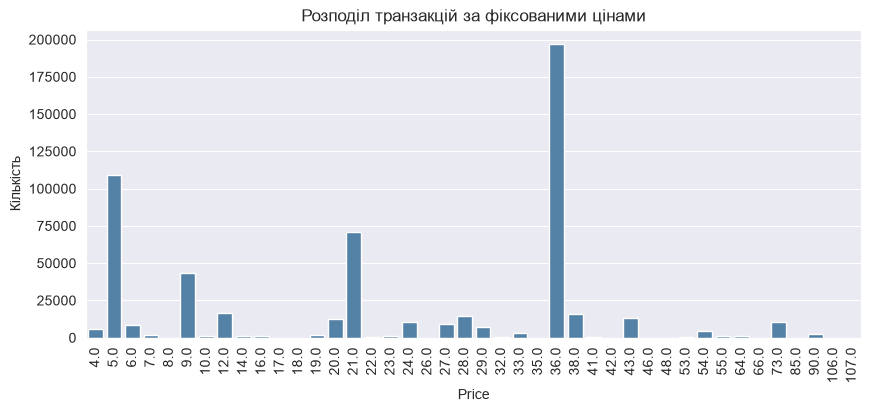

In [11]:
print("Унікальних значень price:", df['price'].nunique())
print(df['price'].value_counts().sort_index())

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='price', order=sorted(df['price'].unique()), color='steelblue')
plt.title('Розподіл транзакцій за фіксованими цінами')
plt.xlabel('Price')
plt.ylabel('Кількість')
plt.xticks(rotation=90)
plt.show()

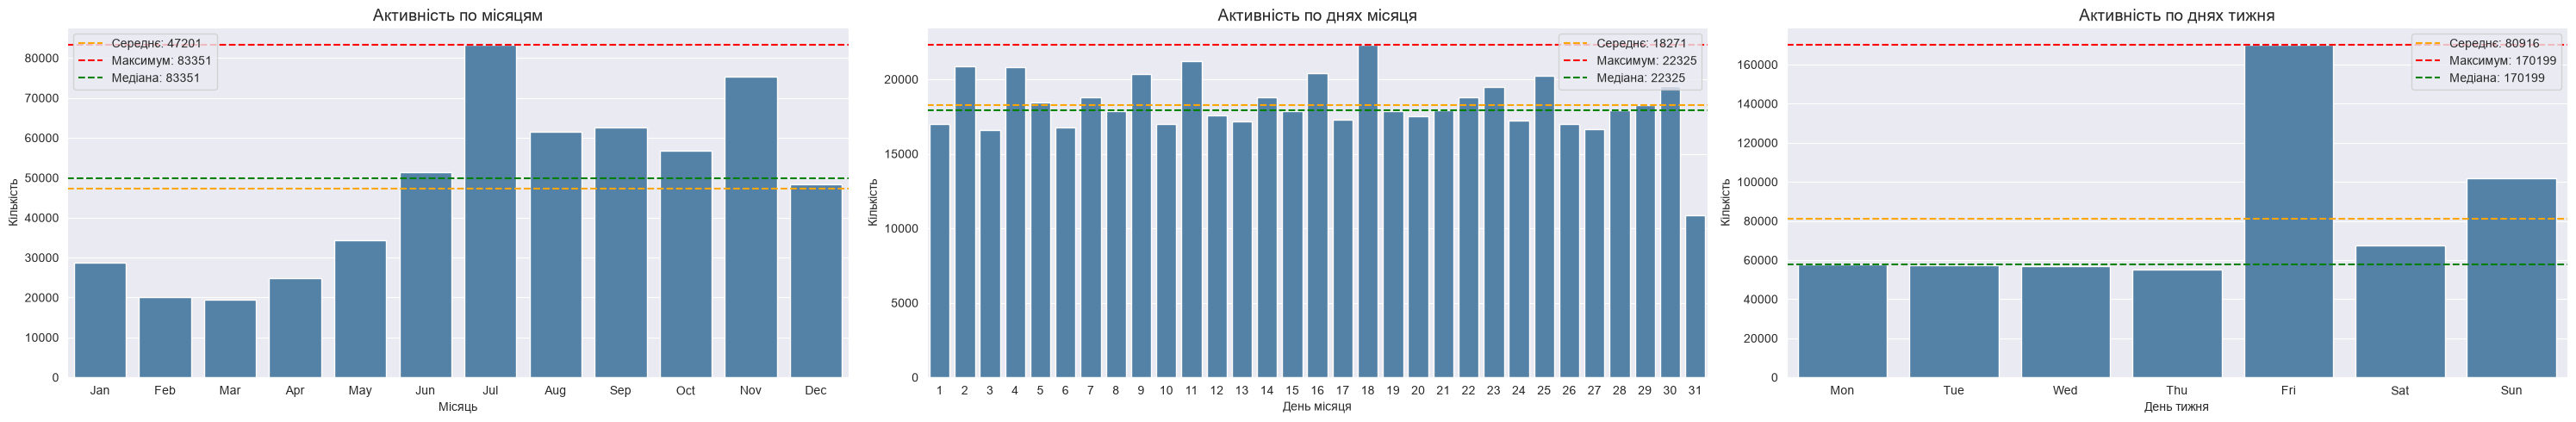

In [12]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

df['dayofweek'] = df['event_time'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(30, 5))

def add_ref_lines(ax, counts):
    mean_val = counts.mean()
    max_val = counts.max()
    median_val = counts.median()
    ax.axhline(mean_val, color='orange', linestyle='--', linewidth=1.5,
               label=f'Середнє: {mean_val:.0f}')
    ax.axhline(max_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Максимум: {max_val:.0f}')
    ax.axhline(median_val, color='green', linestyle='--', linewidth=1.5,
               label=f'Медіана: {max_val:.0f}')
    ax.legend()

# Місяці
month_counts = df['month'].value_counts().sort_index()
sns.countplot(data=df, x='month', order=range(1, 13), ax=axes[0], color='steelblue')
axes[0].set_title('Активність по місяцям', fontsize=14)
axes[0].set_xlabel('Місяць')
axes[0].set_ylabel('Кількість')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month_names)
add_ref_lines(axes[0], month_counts)

# Дні місяця
day_counts = df['day'].value_counts().sort_index()
sns.countplot(data=df, x='day', order=range(1, 32), ax=axes[1], color='steelblue')
axes[1].set_title('Активність по днях місяця', fontsize=14)
axes[1].set_xlabel('День місяця')
axes[1].set_ylabel('Кількість')
add_ref_lines(axes[1], day_counts)

# Дні тижня
dow_counts = df['dayofweek'].value_counts().sort_index()
sns.countplot(data=df, x='dayofweek', order=range(7), ax=axes[2], color='steelblue')
axes[2].set_title('Активність по днях тижня', fontsize=14)
axes[2].set_xlabel('День тижня')
axes[2].set_ylabel('Кількість')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(weekday_names)
add_ref_lines(axes[2], dow_counts)

plt.tight_layout()
plt.show()

In [13]:
df[df['transaction_status']=='fail']['error_type'].value_counts()

error_type
3.02    134691
3.10     44002
3.08     26442
3.04     15163
4.03     12798
4.05     12772
3.01     12658
2.08      8723
0.01      8468
5.01      5945
4.09      4853
5.08      4431
2.06      4055
4.02      3249
2.11      2581
3.03      2334
2.09      1714
4.04      1320
5.04      1312
2.14      1027
2.15      1015
2.02       902
7.01       895
2.01       534
6.01       483
3.05       144
3.07       104
5.03        83
4.01        71
5.11        70
0.03        58
2.10        31
7.07        30
7.03        30
6.02        21
0.02        15
2.16         7
4.06         6
5.02         4
5.06         4
5.07         2
Name: count, dtype: int64

---
# Розшифровка кодів помилок (error_type)

Коди помилок платежів розшифровані за офіційною документацією Solidgate

In [14]:
error_code_map = {
    0.01: "Загальна відмова банку",
    0.02: "Час замовлення вичерпано",
    0.03: "Заборонена операція (юридичні обмеження)",
    2.01: "Помилка валідації даних",
    2.02: "Некоректна сума",
    2.06: "Невірний CVV",
    2.08: "Невірний номер картки",
    2.09: "Невірний термін дії картки",
    2.10: "Помилка 3DS на боці мерчанта",
    2.11: "Помилка 3DS на боці банку",
    2.14: "Помилка підписки",
    2.15: "Потрібна 3D-автентифікація (SCA)",
    2.16: "Підписка заблокована (в процесі створення)",
    3.01: "Картка заблокована банком",
    3.02: "Недостатньо коштів",
    3.03: "Перевищено ліміт суми",
    3.04: "Відхилено банком-емітентом",
    3.05: "Зателефонуйте в банк",
    3.07: "Бренд картки не підтримується",
    3.08: "Do not honor (загальна відмова емітента)",
    3.10: "Підозра на шахрайство",
    4.01: "Картка в чорному списку",
    4.02: "Викрадена картка",
    4.03: "Обмежена картка (заблокована/під санкціями)",
    4.04: "Втрачена картка",
    4.05: "Антифрод еквайра (PSP antifraud)",
    4.06: "Заблоковано за країною/IP",
    4.09: "Стороння антифрод-система",
    5.01: "Помилка 3DS-верифікації",
    5.02: "Невірний токен картки",
    5.03: "Помилка застосунку (технічна)",
    5.04: "Мерчант некоректно налаштований",
    5.06: "Дублікат замовлення",
    5.07: "Перевищено ліміт API-запитів",
    5.08: "Помилка транзакції (технічна)",
    5.11: "Невірний роутинг",
    6.01: "Невідомий код відмови",
    6.02: "Помилка з'єднання",
    7.01: "Токен картки не знайдено",
    7.03: "Smart cascade decline (помилка токена)",
    7.07: "Помилка SCA-рушія",
}

df['error_desc'] = df['error_type'].map(error_code_map)

error_summary = (
    df[df['transaction_status'] == 'fail']['error_desc']
    .value_counts()
    .rename('count')
    .to_frame()
)
error_summary['share_%'] = (error_summary['count'] / error_summary['count'].sum() * 100).round(2)
error_summary.head(15)

,count,share_%
error_desc,,
Недостатньо коштів,134691,43.03
Підозра на шахрайство,44002,14.06
Do not honor (загальна відмова емітента),26442,8.45
Відхилено банком-емітентом,15163,4.84
Обмежена картка (заблокована/під санкціями),12798,4.09
Антифрод еквайра (PSP antifraud),12772,4.08
Картка заблокована банком,12658,4.04
Невірний номер картки,8723,2.79
Загальна відмова банку,8468,2.71


**Висновок:** топ причин відмов — `Недостатньо коштів` (3.02), `Підозра на шахрайство` (3.10), `Do not honor` (3.08), `Картка заблокована` (3.01), `Відхилено емітентом` (3.04). Це вже дає перше уявлення, куди дивитись далі: чи ці частки стабільні протягом року, чи є сплески.

---
# Тренди: обсяг транзакцій та success rate у часі

Дивимось на динаміку по місяцях: чи зростає бізнес (обсяг), і чи змінюється якість платежів (success rate, дохід).

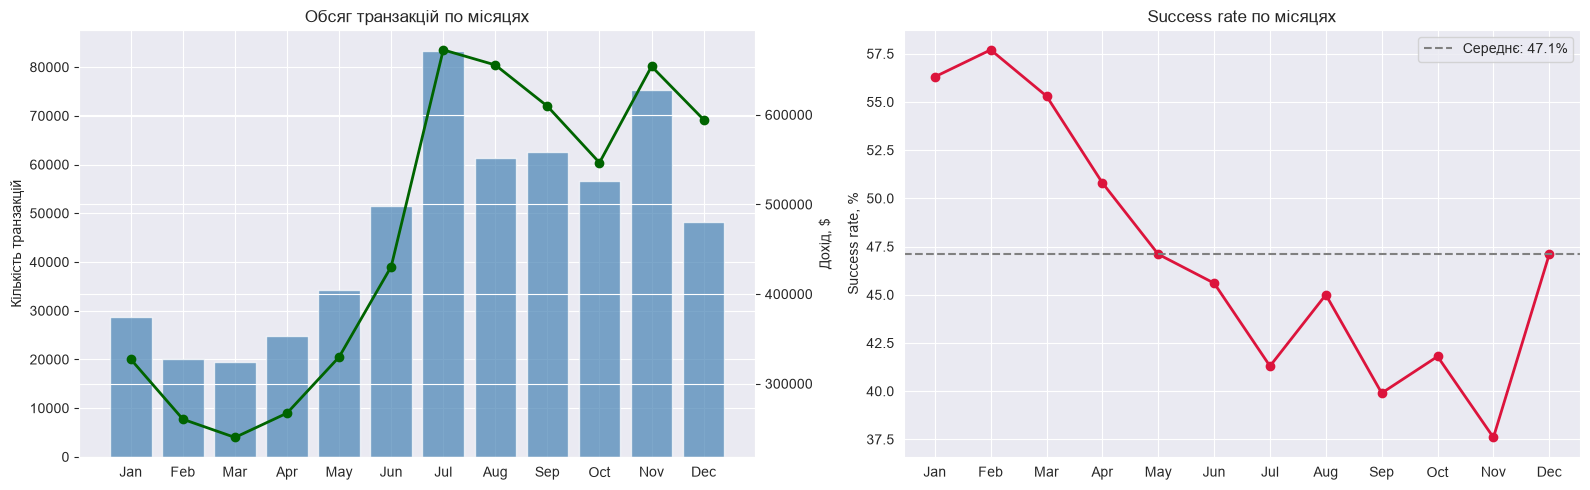

,tx_count,success_count,revenue,success_rate
month,,,,
1,28665,16125,327184.0,56.3
2,20151,11629,260327.0,57.7
3,19452,10765,240012.0,55.3
4,24762,12569,267160.0,50.8
5,34345,16163,329763.0,47.1
6,51452,23463,430580.0,45.6
7,83351,34425,672431.0,41.3
8,61434,27660,655529.0,45.0
9,62598,24952,609529.0,39.9


In [15]:
monthly = df.groupby('month').agg(
    tx_count=('order_id', 'count'),
    success_count=('transaction_status', lambda x: (x == 'success').sum()),
    revenue=('price', lambda x: x[df.loc[x.index, 'transaction_status'] == 'success'].sum())
)
monthly['success_rate'] = (monthly['success_count'] / monthly['tx_count'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(monthly.index, monthly['tx_count'], color='steelblue', alpha=0.7, label='Кількість транзакцій')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel('Кількість транзакцій')
axes[0].set_title('Обсяг транзакцій по місяцях')

ax2 = axes[0].twinx()
ax2.plot(monthly.index, monthly['revenue'], color='darkgreen', marker='o', linewidth=2, label='Дохід (успішні)')
ax2.set_ylabel('Дохід, $')

axes[1].plot(monthly.index, monthly['success_rate'], color='crimson', marker='o', linewidth=2)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Success rate, %')
axes[1].set_title('Success rate по місяцях')
axes[1].axhline(monthly['success_rate'].mean(), color='gray', linestyle='--', label=f"Середнє: {monthly['success_rate'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

monthly

**Ключовий інсайт (тренд):** обсяг транзакцій зростає майже втричі — з ~28.7К у січні до піку ~83К у липні, а success rate за цей же час **падає з 56.3% до 39-41%**. Дохід зростає повільніше за обсяг, бо частка успішних платежів скорочується. Це не випадковий шум — падіння монотонне протягом майже всього року, тож варто розібратись, що саме його спричиняє: реальне погіршення якості трафіку/користувачів, чи конкретна аномалія (один банк, один тип картки, зміна антифрод-правил).

---
## Розбивка success rate: перший платіж (initial) vs повторний (reccurent)

Це критично важливий розріз для підписочного бізнесу: `initial` — конверсія нових користувачів, `reccurent` — утримання/списання з підписки. Якщо тренди розходяться, це різні проблеми з різними причинами.

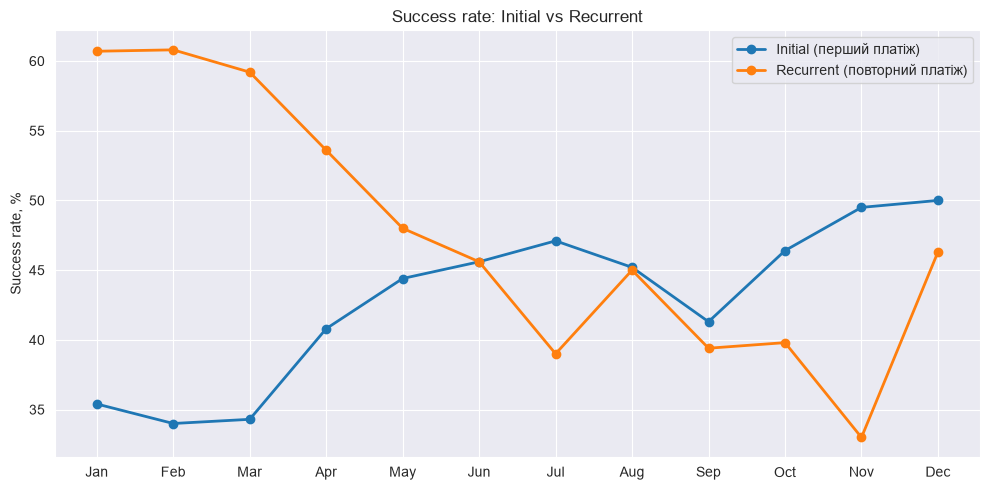

payment_number,initial,reccurent
month,,
1,35.4,60.7
2,34.0,60.8
3,34.3,59.2
4,40.8,53.6
5,44.4,48.0
6,45.6,45.6
7,47.1,39.0
8,45.2,45.0
9,41.3,39.4


In [16]:
sr_pivot = df.groupby(['month', 'payment_number'])['transaction_status'].apply(lambda x: (x == 'success').mean() * 100).unstack().round(1)
vol_pivot = df.groupby(['month', 'payment_number']).size().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sr_pivot.index, sr_pivot['initial'], marker='o', label='Initial (перший платіж)', linewidth=2)
ax.plot(sr_pivot.index, sr_pivot['reccurent'], marker='o', label='Recurrent (повторний платіж)', linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Success rate, %')
ax.set_title('Success rate: Initial vs Recurrent')
ax.legend()
plt.tight_layout()
plt.show()

sr_pivot

**Дуже показовий інсайт:** тренди двох типів платежів рухаються в протилежних напрямках!
- **Initial success rate ЗРОСТАЄ**: з 35,4% (січень) до 50,0% (грудень) — конверсія нових платежів покращується протягом року (ймовірно, оптимізація checkout-флоу чи якості трафіку залучення).
- **Recurrent success rate РІЗКО ПАДАЄ**: з 60,7% (січень) до мінімуму 33,0% (листопад) — майже вдвічі. Саме recurrent-платежі (і їх зростаюча частка в загальному обсязі — 424К проти 142К initial) тягнуть загальний success rate вниз.

Це означає: проблема **не в залученні нових користувачів**, а в **якості вже існуючої бази підписок**, яка обслуговується повторними списаннями.

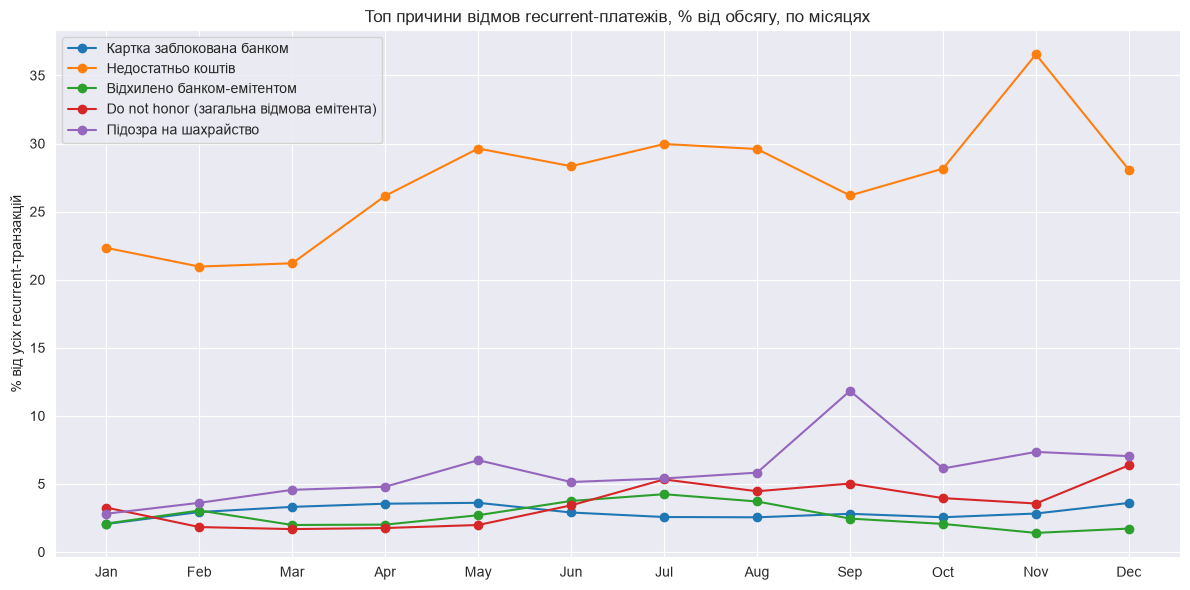

,Картка заблокована банком,Недостатньо коштів,Відхилено банком-емітентом,Do not honor (загальна відмова емітента),Підозра на шахрайство
month,,,,,
1,2.05,22.33,2.08,3.26,2.81
2,2.93,20.96,3.04,1.83,3.61
3,3.31,21.20,1.98,1.68,4.56
4,3.54,26.16,2.00,1.76,4.79
5,3.61,29.63,2.70,1.98,6.74
6,2.90,28.33,3.74,3.42,5.14
7,2.56,29.96,4.24,5.33,5.40
8,2.54,29.60,3.70,4.46,5.82
9,2.80,26.18,2.45,5.02,11.83


In [17]:
fails_rec = df[(df['transaction_status'] == 'fail') & (df['payment_number'] == 'reccurent')]
top_err_codes = fails_rec['error_type'].value_counts().head(5).index.tolist()

err_trend = fails_rec[fails_rec['error_type'].isin(top_err_codes)].groupby(['month', 'error_type']).size().unstack(fill_value=0)
rec_total = df[df['payment_number'] == 'reccurent'].groupby('month').size()
err_trend_pct = err_trend.div(rec_total, axis=0) * 100
err_trend_pct.columns = [error_code_map.get(c, c) for c in err_trend_pct.columns]

fig, ax = plt.subplots(figsize=(12, 6))
for col in err_trend_pct.columns:
    ax.plot(err_trend_pct.index, err_trend_pct[col], marker='o', label=col)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('% від усіх recurrent-транзакцій')
ax.set_title('Топ причини відмов recurrent-платежів, % від обсягу, по місяцях')
ax.legend()
plt.tight_layout()
plt.show()

err_trend_pct.round(2)

**Інсайт:** головний і найбільший драйвер падіння — `Недостатньо коштів` (3.02): зростає з ~22% усіх recurrent-транзакцій у січні до 29-36% у другій половині року. Це класична ознака "виснаження" підписочної бази: що довше живе когорта підписників, то більша частка їхніх карток з часом не має достатньо коштів на регулярне списання (природний involuntary churn). `Підозра на шахрайство` (3.10) також зростає, з піком у вересні (11,8%) — це вже схоже не на поступовий тренд, а на різку зміну, тож розглянемо його окремо як аномалію нижче.

---
# Аномалія №1: банк-емітент SUTTON BANK

При розбивці по банках впадає в очі один банк з екстремально низьким success rate. Досліджуємо його окремо.

In [18]:
bank_stats = df.groupby('bank_name').agg(
    tx_count=('order_id', 'count'),
    success_rate=('transaction_status', lambda x: (x == 'success').mean() * 100)
).sort_values('tx_count', ascending=False)

print("Топ-10 банків за обсягом і їх success rate:")
display(bank_stats.head(10).round(1))

sutton = df[df['bank_name'] == 'SUTTON BANK']
print(f"\nSUTTON BANK: {len(sutton)} транзакцій, success rate = {(sutton['transaction_status']=='success').mean()*100:.1f}%")
print(f"Картки SUTTON BANK: {sutton['card_type'].value_counts().to_dict()}, країна: {sutton['card_country'].unique()}")

Топ-10 банків за обсягом і їх success rate:


,tx_count,success_rate
bank_name,,
SUTTON BANK,29356,15.2
"BANK OF AMERICA, NATIONAL ASSOCIATION",15210,63.1
JPMORGAN CHASE BANK N.A. - DEBIT,15171,68.4
THE BANCORP BANK,14655,27.5
"WELLS FARGO BANK, NATIONAL ASSOCIATION",12900,58.9
COMMONWEALTH BANK OF AUSTRALIA,12251,52.6
"STRIDE BANK, NATIONAL ASSOCIATION",9503,24.5
"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",6944,51.3
THE TORONTO-DOMINION BANK,6792,41.8



SUTTON BANK: 29356 транзакцій, success rate = 15.2%
Картки SUTTON BANK: {'PREPAID': 28250, 'DEBIT': 893, 'CREDIT': 213}, країна: <StringArray>
['USA']
Length: 1, dtype: str


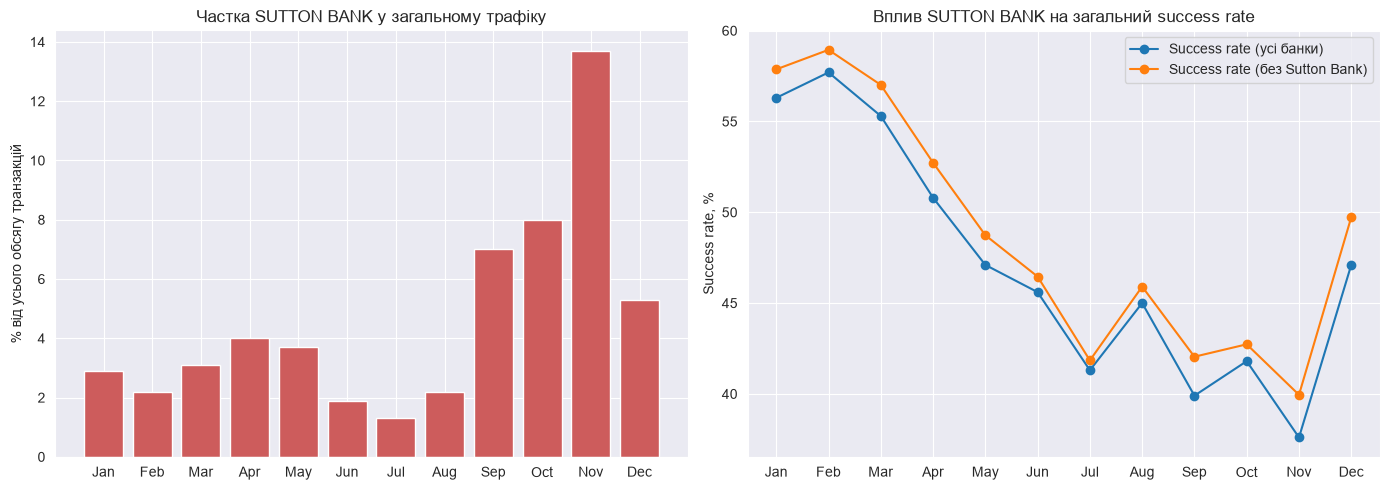

,tx_count,success_rate,share_of_total_%
month,,,
1,828,1.9,2.9
2,437,2.1,2.2
3,600,2.8,3.1
4,1000,4.0,4.0
5,1275,3.6,3.7
6,997,2.3,1.9
7,1110,1.2,1.3
8,1341,5.5,2.2
9,4389,10.9,7.0


In [19]:
sutton_monthly = sutton.groupby('month').agg(
    tx_count=('order_id', 'count'),
    success_rate=('transaction_status', lambda x: (x == 'success').mean() * 100)
)
total_monthly = df.groupby('month').size()
sutton_monthly['share_of_total_%'] = (sutton_monthly['tx_count'] / total_monthly * 100).round(1)

sr_excl_sutton = df[df['bank_name'] != 'SUTTON BANK'].groupby('month')['transaction_status'].apply(lambda x: (x == 'success').mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(sutton_monthly.index, sutton_monthly['share_of_total_%'], color='indianred')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(month_names)
axes[0].set_ylabel('% від усього обсягу транзакцій')
axes[0].set_title('Частка SUTTON BANK у загальному трафіку')

axes[1].plot(monthly.index, monthly['success_rate'], marker='o', label='Success rate (усі банки)')
axes[1].plot(sr_excl_sutton.index, sr_excl_sutton.values, marker='o', label='Success rate (без Sutton Bank)')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Success rate, %')
axes[1].set_title('Вплив SUTTON BANK на загальний success rate')
axes[1].legend()

plt.tight_layout()
plt.show()

sutton_monthly.round(1)

**Аномалія підтверджена:** SUTTON BANK (США, 96% транзакцій — PREPAID картки) має success rate **0.6–5.5%** практично увесь рік (для порівняння: середній по всій базі — 40-58%). Причина відмов — переважно `Підозра на шахрайство` (3.10). Найгірше — обсяг трафіку через цей банк **зростає з 2-4% у першому півріччі до 13.7% у листопаді**, тобто дедалі більша частка загального трафіку — це практично гарантовано неуспішні платежі.

Навіть після виключення SUTTON BANK загальний success rate все одно падає протягом року (з 58% до 40%) — тобто це не єдина причина тренду, але це **окрема, чітко ізольована й дії, що вимагає негайних дій** проблема: одна аномалія на рівні джерела трафіку/банку-емітента, а не поступова природна деградація.

---
# Аномалія №2: різкий стрибок PSP antifraud (4.05) у вересні–листопаді

Ще один код помилки, що привертає увагу — раніше майже відсутній, потім різко зростає.

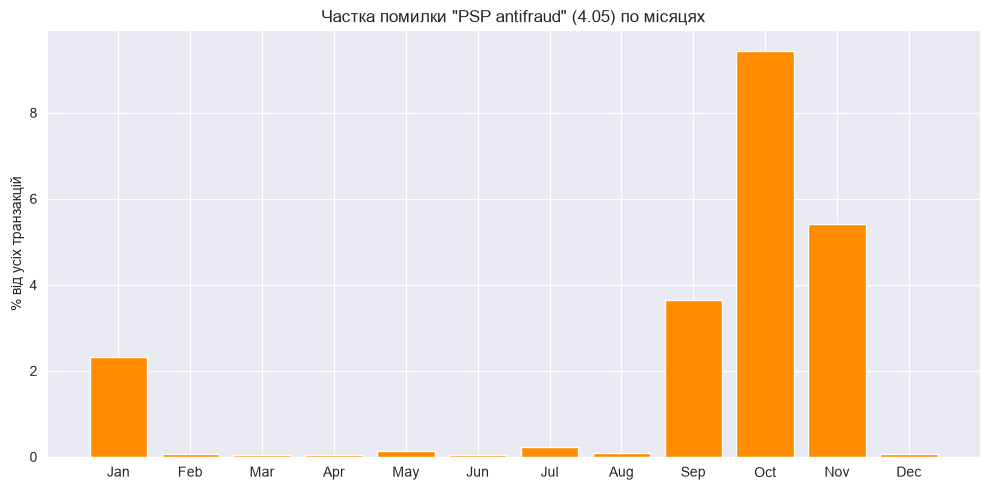

Найбільш уражені card_brand серед 4.05 (вересень-листопад):
card_brand
VISA          6147
MASTERCARD    4191
AMEX          1135
DISCOVER       231
MAESTRO          1
Name: count, dtype: int64

Найбільш уражені card_country серед 4.05 (вересень-листопад), топ-5:
card_country
USA    7859
MEX    2093
BRA     726
ARG     318
AUS     128
Name: count, dtype: int64


month
1     2.33
2     0.06
3     0.04
4     0.04
5     0.14
6     0.05
7     0.24
8     0.10
9     3.64
10    9.44
11    5.42
12    0.07
dtype: float64

In [20]:
err_405 = df[df['error_type'] == 4.05]
m405 = err_405.groupby('month').size()
total_m = df.groupby('month').size()
pct405 = (m405.reindex(range(1,13), fill_value=0) / total_m * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pct405.index, pct405.values, color='darkorange')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.set_ylabel('% від усіх транзакцій')
ax.set_title('Частка помилки "PSP antifraud" (4.05) по місяцях')
plt.tight_layout()
plt.show()

print("Найбільш уражені card_brand серед 4.05 (вересень-листопад):")
print(err_405[err_405['month'].isin([9,10,11])]['card_brand'].value_counts())
print("\nНайбільш уражені card_country серед 4.05 (вересень-листопад), топ-5:")
print(err_405[err_405['month'].isin([9,10,11])]['card_country'].value_counts().head())
pct405

**Аномалія:** код `4.05 – PSP antifraud` практично **відсутній** із січня по серпень (0.0-0.2% транзакцій), а потім **різко з'являється** у вересні (3.9%), досягає піку в жовтні (10.2%) і залишається високим у листопаді (6.3%). Різкий стрибок "з нуля" без поступового наростання — типова ознака **зміни правила/налаштування на боці еквайра чи антифрод-провайдера** (нова антифрод-політика, оновлення скорингової моделі), а не поступової зміни поведінки користувачів. Це варто перевірити безпосередньо з провайдером еквайрингу — чи не змінювались антифрод-правила саме у вересні, і чи не блокує це легітимних клієнтів (false positives).

---
# Підсумкові висновки та рекомендації

## Ключові інсайти

| # | Інсайт | Підтвердження даними |
|---|---|---|
| 1 | Обсяг транзакцій зріс майже втричі за рік, але success rate впав з 56% до ~40% | Місячна динаміка tx_count і success_rate |
| 2 | Проблема концентрована в **recurrent**-платежах (60,7%→33,0%), тоді як **initial** навпаки покращується (35,4%→50,0%) | Розбивка success rate за payment_number |
| 3 | Головний структурний драйвер — зростання частки відмов "Недостатньо коштів" (3.02) у recurrent-платежах (22%→36%) | Тренд error_type серед recurrent fails |
| 4 | **Аномалія:** SUTTON BANK (USA, PREPAID) — success rate 0,6-5,5% увесь рік, а частка в трафіку зросла з ~2% до 13,7% | Помісячна частка та success rate SUTTON BANK |
| 5 | **Аномалія:** різкий стрибок "PSP antifraud" (4.05) з ~0% до 10,2% саме у вересні-жовтні | Помісячна динаміка коду 4.05 |

## Практичні рекомендації для бізнесу

1. **Терміново перевірити джерело трафіку SUTTON BANK.** Success rate <6% при зростаючому обсязі — це або картковий фрод (card testing/carding), або вкрай токсичне джерело трафіку. Рекомендація: тимчасово обмежити приймання PREPAID-карток цього банку/країни або звʼязатися з каналом залучення, що постачає цей трафік.
2. **З'ясувати причину стрибка PSP antifraud (4.05) у вересні.** Звернутися до провайдера еквайрингу/антифроду щодо змін правил саме в цей період. Якщо це false positives — це прямі втрати легітимного доходу, які можна повернути, послабивши правило.
3. **Впровадити retry-логіку та account updater для recurrent-платежів з причиною "Недостатньо коштів".** Це стандартний playbook для involuntary churn: повторні спроби списання через 1–3–7 днів (можливо, після дати зарплати), сервіс оновлення реквізитів картки (account updater), dunning-емейли клієнту про потребу оновити картку.
4. **Розділити моніторинг initial і recurrent success rate як окремі KPI.** Наразі вони рухаються в протилежних напрямках і "маскують" одне одного в загальній метриці — окремий дашборд і алерти для кожного дадуть команді раніше побачити подібні аномалії.
5. **Дослідити суспільне зростання "Підозра на шахрайство" (3.10) поза SUTTON BANK** — перевірити, чи це справді зростання фрод-атак, чи занадто агресивна власна антифрод-система, що блокує легітимних клієнтів.

## Обмеження аналізу
- Немає даних про причини (маркетингові кампанії, зміни цін, нові антифрод-правила) — гіпотези про причини аномалій потребують підтвердження від відповідних команд (маркетинг, ризик-менеджмент, PSP).
- error_type відсутній для ~44% рядків (усі успішні транзакції — це очікувано, там помилки немає), тому весь error-аналіз рахується лише на підмножині fail-транзакцій.